In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "SQLiV3.csv",
    encoding="utf-8",
    on_bad_lines="skip"
)

print("Original dataset shape:", df.shape)

df.head()

Original dataset shape: (30919, 4)


,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN


In [3]:
def fix_label(row):
    for col in ["Label", "Unnamed: 2", "Unnamed: 3"]:
        if col in row.index:
            value = str(row[col]).strip()

            if value in ["0", "1"]:
                return int(value)

    return None


df["Label"] = df.apply(fix_label, axis=1)

df = df.dropna(subset=["Sentence", "Label"]).copy()

df["Label"] = df["Label"].astype(int)

df = df[["Sentence", "Label"]]

print("Dataset shape after label cleaning:", df.shape)

print("\nClass Distribution:")
print(df["Label"].value_counts())

Dataset shape after label cleaning: (30895, 2)

Class Distribution:
Label
0    19530
1    11365
Name: count, dtype: int64


In [4]:
# Convert queries to string
df["Sentence"] = df["Sentence"].astype(str)

# Remove duplicate queries
df = df.drop_duplicates(subset="Sentence")


def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Create cleaned query column
df["clean"] = df["Sentence"].apply(clean_text)

# Remove empty queries
df = df[df["clean"].str.len() > 0]

print("Final dataset shape:", df.shape)

print("\nFinal Class Distribution:")
print(df["Label"].value_counts())

Final dataset shape: (30867, 3)

Final Class Distribution:
Label
0    19510
1    11357
Name: count, dtype: int64


In [5]:
# Create query length column
df["length"] = df["Sentence"].str.len()

print(df.info())

print("\nDataset Description:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 30867 entries, 0 to 30918
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sentence  30867 non-null  object
 1   Label     30867 non-null  int64 
 2   clean     30867 non-null  object
 3   length    30867 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1.2+ MB
None

Dataset Description:
              Label        length
count  30867.000000  30867.000000
mean       0.367933     69.003758
std        0.482251     81.130305
min        0.000000      1.000000
25%        0.000000     21.000000
50%        0.000000     48.000000
75%        1.000000     81.000000
max        1.000000   5370.000000


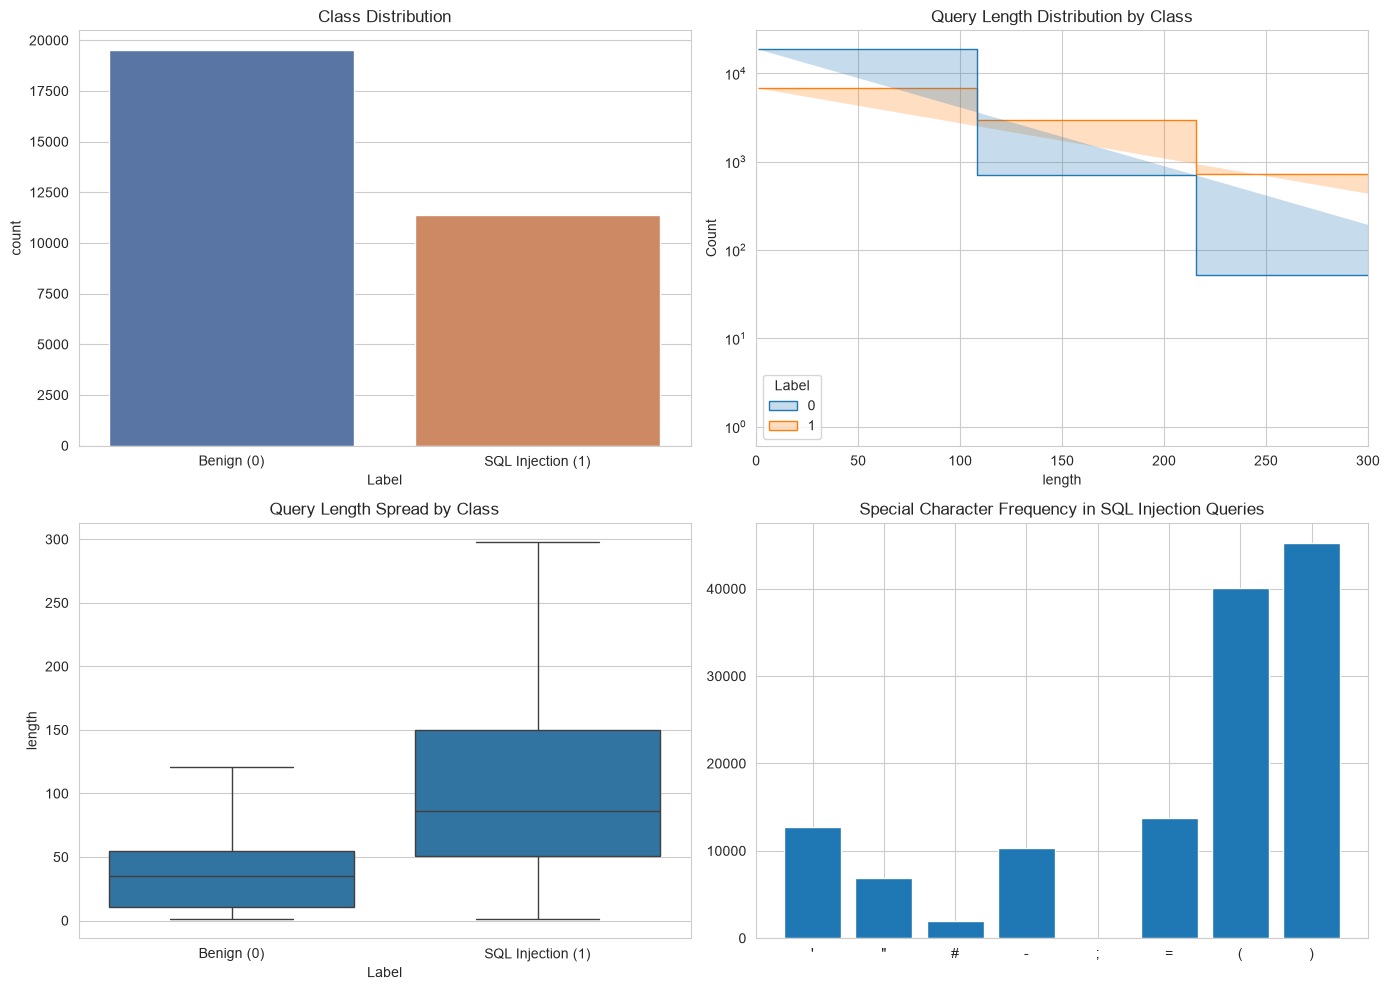

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# -----------------------------------
# 1. Class Distribution
# -----------------------------------

sns.countplot(
    x="Label",
    hue="Label",
    data=df,
    ax=axes[0, 0],
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

axes[0, 0].set_title("Class Distribution")

axes[0, 0].set_xticks([0, 1])

axes[0, 0].set_xticklabels([
    "Benign (0)",
    "SQL Injection (1)"
])


# -----------------------------------
# 2. Query Length Distribution
# -----------------------------------

sns.histplot(
    data=df,
    x="length",
    hue="Label",
    bins=50,
    element="step",
    log_scale=(False, True),
    ax=axes[0, 1]
)

axes[0, 1].set_xlim(0, 300)

axes[0, 1].set_title(
    "Query Length Distribution by Class"
)


# -----------------------------------
# 3. Query Length Boxplot
# -----------------------------------

sns.boxplot(
    x="Label",
    y="length",
    data=df,
    ax=axes[1, 0],
    showfliers=False
)

axes[1, 0].set_title(
    "Query Length Spread by Class"
)

axes[1, 0].set_xticks([0, 1])

axes[1, 0].set_xticklabels([
    "Benign (0)",
    "SQL Injection (1)"
])


# -----------------------------------
# 4. Special Character Frequency
# -----------------------------------

special_chars = "'\"#-;=()"

counts = Counter()

for query in df.loc[df["Label"] == 1, "Sentence"]:

    for char in special_chars:
        counts[char] += query.count(char)


chars = list(counts.keys())

values = list(counts.values())


axes[1, 1].bar(chars, values)

axes[1, 1].set_title(
    "Special Character Frequency in SQL Injection Queries"
)


plt.tight_layout()

plt.show()

In [7]:
X = df["clean"]

y = df["Label"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

Training samples: 24693
Testing samples: 6174


In [8]:
vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(1, 3),
    max_features=5000
)


X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)


print("Training feature shape:", X_train_vec.shape)

print("Testing feature shape:", X_test_vec.shape)

Training feature shape: (24693, 5000)
Testing feature shape: (6174, 5000)


In [9]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)


lr.fit(X_train_vec, y_train)


pred_lr = lr.predict(X_test_vec)


print("===== Logistic Regression =====\n")

print(
    classification_report(
        y_test,
        pred_lr
    )
)


lr_accuracy = accuracy_score(
    y_test,
    pred_lr
)

print("Accuracy:", lr_accuracy)

===== Logistic Regression =====

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3902
           1       1.00      0.99      0.99      2272

    accuracy                           0.99      6174
   macro avg       0.99      0.99      0.99      6174
weighted avg       0.99      0.99      0.99      6174

Accuracy: 0.9933592484612893


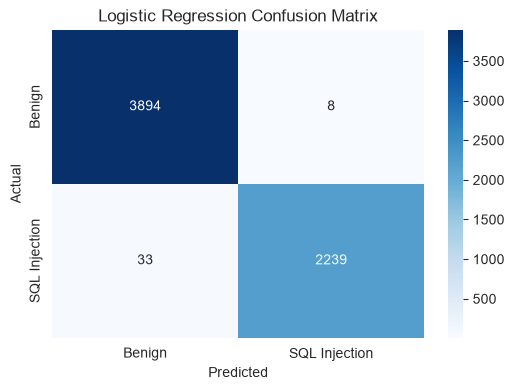

In [10]:
cm_lr = confusion_matrix(
    y_test,
    pred_lr
)


plt.figure(figsize=(6, 4))


sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "SQL Injection"],
    yticklabels=["Benign", "SQL Injection"]
)


plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


rf.fit(
    X_train_vec,
    y_train
)


pred_rf = rf.predict(
    X_test_vec
)


print("===== Random Forest =====\n")

print(
    classification_report(
        y_test,
        pred_rf
    )
)


rf_accuracy = accuracy_score(
    y_test,
    pred_rf
)

print("Accuracy:", rf_accuracy)

===== Random Forest =====

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3902
           1       1.00      0.99      1.00      2272

    accuracy                           1.00      6174
   macro avg       1.00      1.00      1.00      6174
weighted avg       1.00      1.00      1.00      6174

Accuracy: 0.9965986394557823


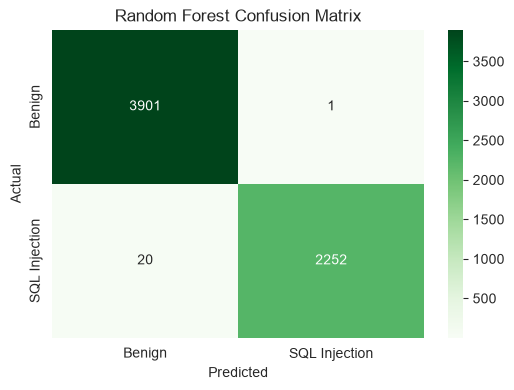

In [12]:
cm_rf = confusion_matrix(
    y_test,
    pred_rf
)


plt.figure(figsize=(6, 4))


sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "SQL Injection"],
    yticklabels=["Benign", "SQL Injection"]
)


plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [13]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=30,
    random_state=42,
    early_stopping=True
)


mlp.fit(
    X_train_vec,
    y_train
)


pred_mlp = mlp.predict(
    X_test_vec
)


print("===== MLP Neural Network =====\n")

print(
    classification_report(
        y_test,
        pred_mlp
    )
)


mlp_accuracy = accuracy_score(
    y_test,
    pred_mlp
)

print("Accuracy:", mlp_accuracy)

===== MLP Neural Network =====

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3902
           1       1.00      0.99      0.99      2272

    accuracy                           1.00      6174
   macro avg       1.00      0.99      1.00      6174
weighted avg       1.00      1.00      1.00      6174

Accuracy: 0.9957887917071591


In [14]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "MLP Neural Network"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        mlp_accuracy
    ]
})


results = results.sort_values(
    by="Accuracy",
    ascending=False
)


print("===== FINAL MODEL COMPARISON =====\n")

print(results)

===== FINAL MODEL COMPARISON =====

                 Model  Accuracy
1        Random Forest  0.996599
2   MLP Neural Network  0.995789
0  Logistic Regression  0.993359


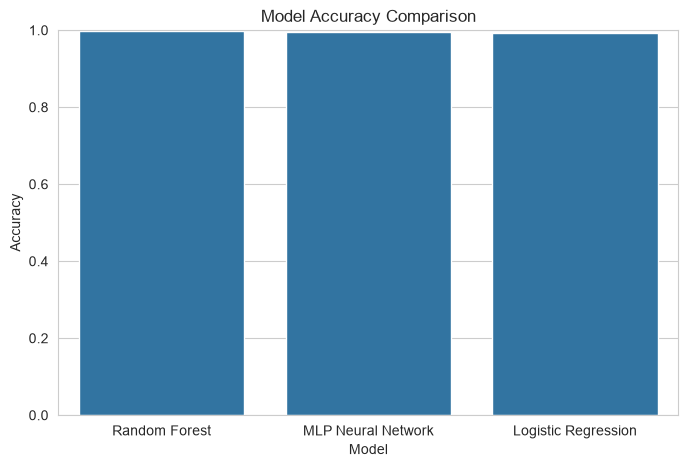

In [15]:
plt.figure(figsize=(8, 5))


sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)


plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)

plt.show()

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score
model_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "MLP Neural Network"
    ],

    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_mlp)
    ],

    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_mlp)
    ],

    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_mlp)
    ],

    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_mlp)
    ]
})

model_metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.993359,0.996440,0.985475,0.990927
1,Random Forest,0.996599,0.999556,0.991197,0.995359
2,MLP Neural Network,0.995789,0.997784,0.990757,0.994258


In [17]:
from sklearn.metrics import roc_auc_score
lr_prob = lr.predict_proba(X_test_vec)[:, 1]

rf_prob = rf.predict_proba(X_test_vec)[:, 1]

mlp_prob = mlp.predict_proba(X_test_vec)[:, 1]


print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, lr_prob))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

print("MLP ROC-AUC:",
      roc_auc_score(y_test, mlp_prob))

Logistic Regression ROC-AUC: 0.9979856393615408
Random Forest ROC-AUC: 0.9996323887713776
MLP ROC-AUC: 0.999183449621357


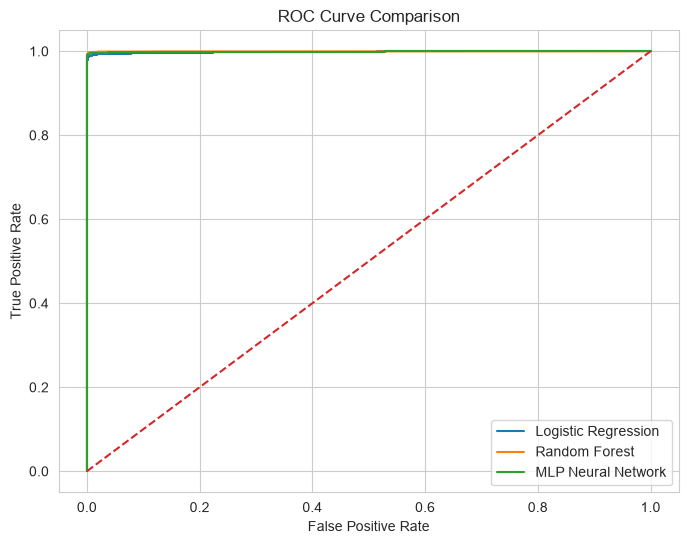

In [19]:
from sklearn.metrics import roc_curve
models_probabilities = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "MLP Neural Network": mlp_prob
}


plt.figure(figsize=(8, 6))


for model_name, probabilities in models_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=model_name
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [20]:
feature_names = vectorizer.get_feature_names_out()

coefficients = lr.coef_[0]


feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
})


top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)


top_features


,Feature,Importance
634,",",9.051499
0,,7.008288
757,-,6.691696
479,#,4.160968
480,#,3.989788
226,=,3.943085
225,=,3.943085
2293,=,3.943085
2294,=,3.943085
90,-,3.918986


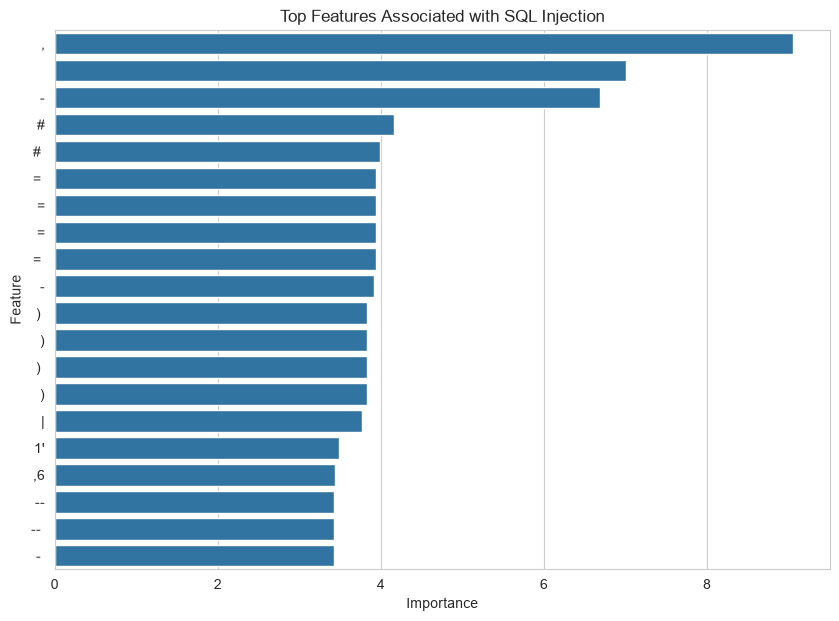

In [21]:
plt.figure(figsize=(10, 7))


sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)


plt.title(
    "Top Features Associated with SQL Injection"
)


plt.show()

In [22]:
best_model = model_metrics.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]


print("Best Model:")

print(best_model)

Best Model:
Model        Random Forest
Accuracy          0.996599
Precision         0.999556
Recall            0.991197
F1 Score          0.995359
Name: 1, dtype: object


In [23]:
import joblib
joblib.dump(
    lr,
    "sql_injection_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [24]:
model = joblib.load(
    "sql_injection_model.pkl"
)

vectorizer = joblib.load(
    "tfidf_vectorizer.pkl"
)

In [25]:
def predict_query(query):

    cleaned_query = clean_text(query)

    query_vector = vectorizer.transform(
        [cleaned_query]
    )

    prediction = lr.predict(
        query_vector
    )[0]

    probability = lr.predict_proba(
        query_vector
    )[0][1]


    if prediction == 1:

        print("⚠️ SQL Injection Detected")

    else:

        print("✅ Benign Query")


    print(
        f"SQL Injection Probability: "
        f"{probability:.4f}"
    )

In [26]:
predict_query("your test query here")

✅ Benign Query
SQL Injection Probability: 0.0119


In [27]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    lr,
    vectorizer.transform(df["clean"]),
    df["Label"],
    cv=5,
    scoring="f1"
)


print("Cross Validation Scores:")

print(cv_scores)


print("\nAverage F1 Score:")

print(cv_scores.mean())

Cross Validation Scores:
[0.96255708 0.99977988 0.95372318 0.99889989 0.99268455]

Average F1 Score:
0.9815289156220987
